# Logistic Regression for Return Direction Prediction

**Docker image**: `ml4t`

**Purpose**: apply logistic regression to predict the direction of 21-day forward
returns on the ETF panel, using the same walk-forward folds as
`02_regularization_paths`.

**Learning objectives**

- Convert a continuous return label into a binary classification target
- Fit L2- and L1-regularized logistic regression on walk-forward folds
- Evaluate with classification metrics: accuracy, AUC-ROC, precision, recall
- Assess probability calibration and its importance for position sizing
- Compare feature importance from L1 logistic coefficients

**Book reference**: Section 11.3 — Predicting Direction with Logistic Regression.

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- Walk-forward CV configuration in `case_studies/etfs/config/setup.yaml`

**Downstream**: `04_nested_cv_hpo` (HPO with nested CV), `06_conformal_prediction`
(uncertainty quantification), Ch12 (gradient boosting on the same task).

## Setup

In [1]:
"""Logistic Regression for Return Direction Prediction — classify return direction with calibration analysis."""

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir, get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
RETRAIN = False

In [3]:
RANDOM_SEED = SEED
set_global_seeds(SEED)

## Load Features and Labels

We reuse the same pre-computed features (Ch8) and 21-day forward return labels
(Ch7) as `02_regularization_paths`. The only difference is that we convert the
continuous return into a binary direction target.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

### Create Binary Direction Target

We convert the continuous 21-day forward return into a binary label:
1 if the return is positive (up), 0 otherwise (down). This transforms
the regression problem from NB02 into a classification problem.

In [5]:
RETURN_COL = "fwd_ret_21d"
TARGET_COL = "direction"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner").with_columns(
    (pl.col(RETURN_COL) > 0).cast(pl.Int32).alias(TARGET_COL),
)

META_COLS = {"timestamp", ASSET_COL, RETURN_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 393,985 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


### Class Balance

A significant imbalance would require stratified sampling or reweighting.
With 21-day returns on diversified ETFs over a long-term bull market, we
expect a moderate positive skew.

In [6]:
up_count = df.filter(pl.col(TARGET_COL) == 1).height
down_count = df.filter(pl.col(TARGET_COL) == 0).height
print(f"Up (1):   {up_count:>8,}  ({up_count / df.height:.1%})")
print(f"Down (0): {down_count:>8,}  ({down_count / df.height:.1%})")

Up (1):    233,818  (59.3%)
Down (0):  160,167  (40.7%)


## Walk-Forward Cross-Validation Setup

We reuse the same walk-forward splits from `setup.yaml` as
`02_regularization_paths`: rolling train/validation windows with purge gap.

In [7]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
return_array = df[RETURN_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()

cv_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    cv_splits.append((train_idx, test_idx))

train_sizes = [len(tr) for tr, _ in cv_splits]
test_sizes = [len(te) for _, te in cv_splits]
if cv_splits:
    print(
        f"{len(cv_splits)} walk-forward folds — train size "
        f"{min(train_sizes):,}–{max(train_sizes):,}, test size "
        f"{min(test_sizes):,}–{max(test_sizes):,}"
    )
else:
    print("0 walk-forward folds — every candidate split failed the train/test size gate")

8 walk-forward folds — train size 157,172–226,959, test size 22,170–24,192


## Helper Functions

### Solver Selection

sklearn's `LogisticRegression` offers several solvers optimized for different
penalty structures:

| Solver | L1 | L2 | ElasticNet | Multinomial | Best for |
|------------|----|----|------------|-------------|----------------------------------------------|
| `lbfgs` | — | yes | — | yes | Default L2; fast quasi-Newton |
| `liblinear` | yes | yes | — | — | Pure L1 binary; coordinate descent |
| `saga` | yes | yes | yes | yes | ElasticNet, large $n$, `sample_weight` |

We use `lbfgs` for L2 (fast, numerically stable), `liblinear` for pure L1
binary classification (coordinate descent is ~6x faster than `saga` for this
case), and `saga` only when ElasticNet mixing is needed.

In [8]:
def evaluate_classification(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Classification metrics: accuracy, precision, recall, F1, AUC-ROC, log-loss."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        "log_loss": log_loss(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

### Walk-Forward Logistic CV
Run logistic regression on walk-forward folds with per-fold preprocessing.

In [9]:
def cross_validate_logistic(
    l1_ratio: float = 0.0,
    C: float = 1.0,
) -> tuple[list[dict], list[np.ndarray], list[dict], list[dict]]:
    """Run logistic regression on walk-forward folds.

    Returns per-fold metrics, coefficient arrays, prediction dicts,
    and fitted (model, scaler) pairs for persistence.
    """
    # Select penalty and solver based on l1_ratio
    if l1_ratio == 0.0:
        penalty, solver = "l2", "lbfgs"
        model_kwargs = {}
    elif l1_ratio == 1.0:
        penalty, solver = "l1", "liblinear"
        model_kwargs = {}
    else:
        penalty, solver = "elasticnet", "saga"
        model_kwargs = {"l1_ratio": l1_ratio}

    results, coefficients, predictions, fold_models = [], [], [], []

    for i, (train_idx, test_idx) in enumerate(cv_splits):
        X_tr, X_te = features_array[train_idx], features_array[test_idx]
        y_tr, y_te = target_array[train_idx], target_array[test_idx]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=1000,
            random_state=RANDOM_SEED,
            **model_kwargs,
        )
        model.fit(X_tr_s, y_tr)

        y_pred = model.predict(X_te_s)
        y_prob = model.predict_proba(X_te_s)[:, 1]

        metrics = evaluate_classification(y_te, y_pred, y_prob)
        metrics["fold"] = i + 1
        results.append(metrics)
        coefficients.append(model.coef_.ravel().copy())

        predictions.append(
            {
                "y_true": y_te,
                "y_pred": y_pred,
                "y_prob": y_prob,
                "returns": return_array[test_idx],
            }
        )
        fold_models.append({"model": model, "scaler": scaler})

    return results, coefficients, predictions, fold_models

## Model Cache

Training results are cached to disk so subsequent runs skip model fitting.
Set `RETRAIN = True` to force retraining.

In [10]:
MODELS_DIR = get_chapter_dir(11) / "models" / "03_logistic_classification"
RESULTS_PATH = MODELS_DIR / "cv_results.joblib"
NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()

if not NEED_TRAINING:
    _cached = joblib.load(RESULTS_PATH)
    required_keys = {"l2_all", "l2_summary", "best_l2_C", "l1_all", "l1_summary", "best_l1_C"}
    missing_keys = sorted(required_keys - set(_cached.keys()))
    if missing_keys:
        raise KeyError(
            "Cache schema mismatch for 03_logistic_classification. "
            f"Missing keys: {missing_keys}. "
            "Delete stale cache and rerun with RETRAIN=True once to regenerate."
        )
    l2_all = _cached["l2_all"]
    l2_summary = _cached["l2_summary"]
    best_l2_C = _cached["best_l2_C"]
    l1_all = _cached["l1_all"]
    l1_summary = _cached["l1_summary"]
    best_l1_C = _cached["best_l1_C"]
    del _cached
    print(f"  L2: {len(l2_all)} C values | L1: {len(l1_all)} C values")
else:
    print("Training models (RETRAIN=True or no cache found)...")

  L2: 6 C values | L1: 5 C values


## L2 Regularized Logistic Regression (Ridge)

The regularization parameter $C$ is the *inverse* of penalty strength:
small $C$ means strong regularization. We sweep six values from heavy
($C=0.001$) to light ($C=100$) regularization.

In [11]:
if NEED_TRAINING:
    L2_C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

    l2_all = {}
    for C in L2_C_VALUES:
        res, coeffs, preds, models = cross_validate_logistic(l1_ratio=0.0, C=C)
        l2_all[C] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "predictions": preds,
            "models": models,
        }

    l2_summary = pl.DataFrame(
        [
            {
                "C": C,
                "mean_acc": d["results"]["accuracy"].mean(),
                "mean_auc": d["results"]["auc_roc"].mean(),
                "mean_f1": d["results"]["f1"].mean(),
            }
            for C, d in l2_all.items()
        ]
    ).sort("mean_auc", descending=True)

    best_l2_C = l2_summary.row(0, named=True)["C"]

In [12]:
print(
    f"Best L2 C: {best_l2_C}  AUC: {l2_summary.filter(pl.col('C') == best_l2_C)['mean_auc'].item():.4f}"
)
l2_summary

Best L2 C: 0.01  AUC: 0.5695


C,mean_acc,mean_auc,mean_f1
f64,f64,f64,f64
0.01,0.560596,0.569502,0.642306
0.1,0.547449,0.568664,0.619218
1.0,0.544701,0.567639,0.613945
10.0,0.544607,0.567607,0.613698
100.0,0.544547,0.567482,0.61354
0.001,0.585747,0.557149,0.689056


### Effect of Class Weighting

`class_weight='balanced'` scales each class's loss contribution inversely
by its frequency. Even with only mildly imbalanced 21-day ETF returns (59/41)
the effect is large and one-sided: up-weighting the minority "down" class
collapses recall on the majority "up" class (0.35 -> 0.11) and roughly halves
F1 (0.46 -> 0.19), because the classifier now predicts "down" far more often.
The lesson is that `balanced` is a strong intervention even at mild imbalance —
it trades majority-class recall for minority-class sensitivity, which is what
you want for rare-event prediction but not here.

In [13]:
train_idx_cw, test_idx_cw = cv_splits[-1]
scaler_cw = StandardScaler()
X_tr_cw = scaler_cw.fit_transform(features_array[train_idx_cw])
X_te_cw = scaler_cw.transform(features_array[test_idx_cw])
y_tr_cw, y_te_cw = target_array[train_idx_cw], target_array[test_idx_cw]

rows_cw = []
for cw_label, cw_val in [("None", None), ("Balanced", "balanced")]:
    m = LogisticRegression(
        C=best_l2_C,
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_SEED,
        class_weight=cw_val,
    )
    m.fit(X_tr_cw, y_tr_cw)
    yp = m.predict_proba(X_te_cw)[:, 1]
    rows_cw.append(
        {
            "class_weight": cw_label,
            **evaluate_classification(y_te_cw, (yp >= 0.5).astype(int), yp),
        }
    )

pl.DataFrame(rows_cw)

class_weight,accuracy,precision,recall,f1,auc_roc,log_loss
str,f64,f64,f64,f64,f64,f64
"""None""",0.476816,0.666086,0.353221,0.461638,0.549125,0.717478
"""Balanced""",0.402436,0.676733,0.113005,0.19367,0.548071,0.78082


## L1 Regularized Logistic Regression (LASSO)

L1 regularization drives some coefficients to exactly zero, performing
automatic feature selection — the same sparsity effect we saw with LASSO
regression in NB02.

In [14]:
if NEED_TRAINING:
    L1_C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0]

    l1_all = {}
    for C in L1_C_VALUES:
        res, coeffs, preds, models = cross_validate_logistic(l1_ratio=1.0, C=C)
        l1_all[C] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "predictions": preds,
            "models": models,
        }

    l1_summary = pl.DataFrame(
        [
            {
                "C": C,
                "mean_acc": d["results"]["accuracy"].mean(),
                "mean_auc": d["results"]["auc_roc"].mean(),
                "mean_f1": d["results"]["f1"].mean(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum()),
            }
            for C, d in l1_all.items()
        ]
    ).sort("mean_auc", descending=True)

    best_l1_C = l1_summary.row(0, named=True)["C"]

In [15]:
print(
    f"Best L1 C: {best_l1_C}  AUC: {l1_summary.filter(pl.col('C') == best_l1_C)['mean_auc'].item():.4f}"
)
l1_summary

Best L1 C: 10.0  AUC: 0.5673


C,mean_acc,mean_auc,mean_f1,n_nonzero
f64,f64,f64,f64,i64
10.0,0.544564,0.56729,0.613557,57
0.1,0.550819,0.567238,0.625992,55
1.0,0.544723,0.567237,0.614307,56
0.01,0.570854,0.555843,0.666683,41
0.001,0.592655,0.512776,0.721817,8


### Save / Load Cache

In [16]:
if NEED_TRAINING:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "l2_all": l2_all,
            "l2_summary": l2_summary,
            "best_l2_C": best_l2_C,
            "l1_all": l1_all,
            "l1_summary": l1_summary,
            "best_l1_C": best_l1_C,
        },
        RESULTS_PATH,
    )
    print(f"Saved results to {RESULTS_PATH}")

## Model Comparison

We compare the best L2 and L1 configurations against a naive baseline
that always predicts the majority class.

In [17]:
naive_acc = max(up_count, down_count) / df.height

rows = []
for label, res_df in [
    (f"Logistic L2 (C={best_l2_C})", l2_all[best_l2_C]["results"]),
    (f"Logistic L1 (C={best_l1_C})", l1_all[best_l1_C]["results"]),
]:
    rows.append(
        {
            "Model": label,
            "Accuracy": round(res_df["accuracy"].mean(), 4),
            "AUC-ROC": round(res_df["auc_roc"].mean(), 4),
            "Precision": round(res_df["precision"].mean(), 4),
            "Recall": round(res_df["recall"].mean(), 4),
            "F1": round(res_df["f1"].mean(), 4),
            "Log-Loss": round(res_df["log_loss"].mean(), 4),
        }
    )

rows.append(
    {
        "Model": "Naive (majority class)",
        "Accuracy": round(naive_acc, 4),
        "AUC-ROC": 0.5,
        "Precision": 0.0,
        "Recall": 0.0,
        "F1": 0.0,
        "Log-Loss": round(-np.log(naive_acc), 4),
    }
)

comparison = pl.DataFrame(rows)
comparison

Model,Accuracy,AUC-ROC,Precision,Recall,F1,Log-Loss
str,f64,f64,f64,f64,f64,f64
"""Logistic L2 (C=0.01)""",0.5606,0.5695,0.6493,0.7041,0.6423,0.698
"""Logistic L1 (C=10.0)""",0.5446,0.5673,0.6468,0.6561,0.6136,0.7192
"""Naive (majority class)""",0.5935,0.5,0.0,0.0,0.0,0.5218


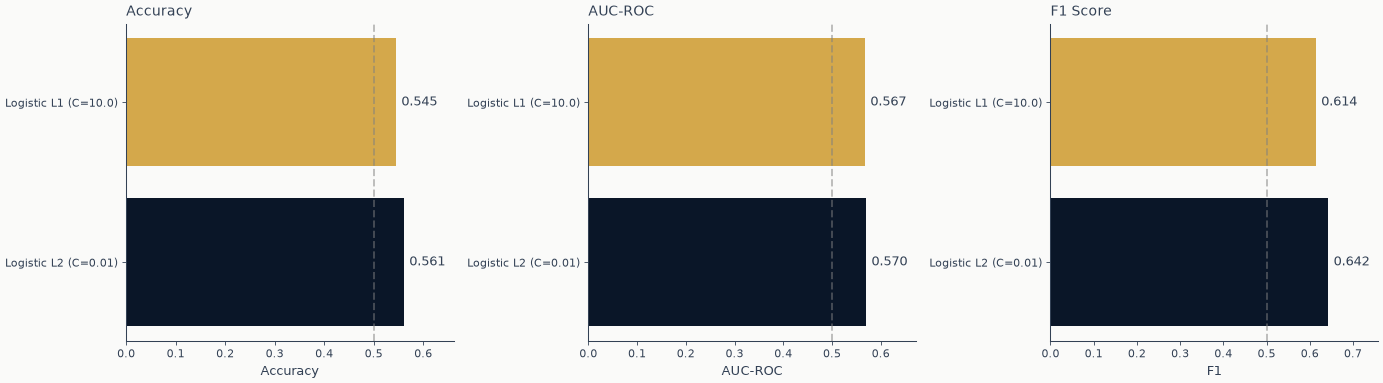

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

model_names = comparison["Model"].to_list()[:2]
x = np.arange(len(model_names))
bar_colors = [COLORS["blue"], COLORS["amber"]]

for ax, metric, title in zip(
    axes,
    ["Accuracy", "AUC-ROC", "F1"],
    ["Accuracy", "AUC-ROC", "F1 Score"],
    strict=False,
):
    vals = comparison[metric].to_list()[:2]
    bars = ax.barh(x, vals, color=bar_colors)
    for bar, val in zip(bars, vals, strict=False):
        ax.text(
            val + max(vals) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=9,
        )
    ax.set_yticks(x)
    ax.set_yticklabels(model_names)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.axvline(0.5, ls="--", color="grey", alpha=0.5)
    ax.set_xlim(0, max(vals) * 1.18)

fig.tight_layout()
fig.show()

**Interpretation**: both models reach AUC-ROC $\approx 0.57$, above the 0.50
value a constant predictor obtains by definition; the features carry some
directional signal at the 0.5 threshold the logistic model uses. Accuracy
(0.54–0.56) falls *below* the naive majority-class accuracy (0.59), because
the 0.5 probability threshold is suboptimal for the 62/38 class imbalance —
the model gives up accuracy in exchange for ranking ability across thresholds,
which is what AUC-ROC measures. L2 and L1 produce similar AUC and accuracy
here; the ETF feature set has many correlated predictors and the L1 sparsity
advantage does not translate into a different operating point.

## Detailed Classification Analysis

We aggregate out-of-sample predictions across all 8 folds for the best L2 model
to examine the confusion matrix, ROC curve, and precision-recall tradeoff.

In [19]:
best_preds = l2_all[best_l2_C]["predictions"]

all_y_true = np.concatenate([p["y_true"] for p in best_preds])
all_y_prob = np.concatenate([p["y_prob"] for p in best_preds])
all_y_pred = (all_y_prob >= 0.5).astype(int)

### Confusion Matrix

In [20]:
cm = confusion_matrix(all_y_true, all_y_pred)
# sklearn returns rows = actual, cols = predicted: cm[i, j] = count(y_true=i, y_pred=j).
pl.DataFrame(
    {
        "Actual": ["Down", "Up"],
        "Predicted Down": [cm[0, 0], cm[1, 0]],
        "Predicted Up": [cm[0, 1], cm[1, 1]],
    }
)

Actual,Predicted Down,Predicted Up
str,i64,i64
"""Down""",2364,4873
"""Up""",3537,8378


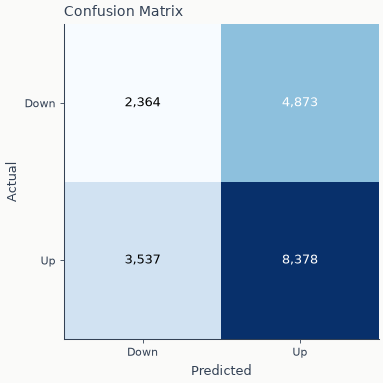

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Down", "Up"])
ax.set_yticklabels(["Down", "Up"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

fig.tight_layout()
fig.show()

The off-diagonal entries are *not* symmetric: the model predicts Up about
69% of the time despite a 62/38 actual base rate, so false positives
(Actual Down → Predicted Up) substantially outnumber false negatives. The
0.5 decision threshold is suboptimal for this base rate — Section 11.5
returns to threshold tuning under conformal coverage targets.

### ROC Curve

The ROC curve plots the true positive rate against the false positive rate
at various probability thresholds. An AUC above 0.5 indicates the model
does better than random coin-flipping.

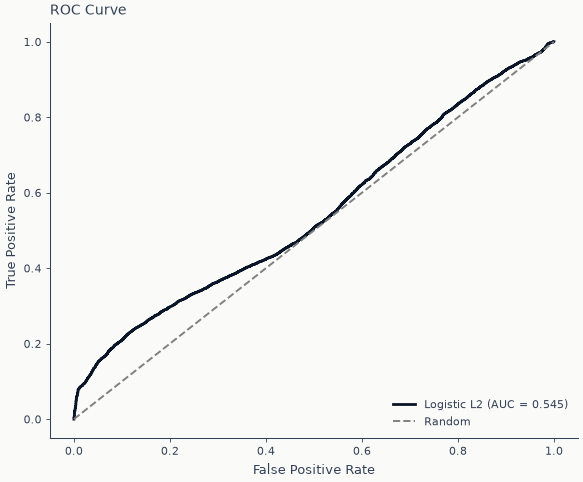

In [22]:
# Manual argsort+cumsum ROC sweep. sklearn's _binary_clf_curve raises a
# state-dependent IndexError on some score arrays under the pinned
# scikit-learn / numpy 2.x stack; this path is the exact ROC definition,
# deterministic, and equivalent on these scores.
auc_val = roc_auc_score(all_y_true, all_y_prob)
_order = np.argsort(-all_y_prob, kind="mergesort")
_yt_sorted = all_y_true[_order].astype(np.int64)
_n_pos = int(_yt_sorted.sum())
_n_neg = len(_yt_sorted) - _n_pos
fpr = np.concatenate([[0.0], np.cumsum(1 - _yt_sorted) / _n_neg])
tpr = np.concatenate([[0.0], np.cumsum(_yt_sorted) / _n_pos])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f"Logistic L2 (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")
fig.tight_layout()
fig.show()

### Precision-Recall Curve

For imbalanced classes or when the cost of false positives is high,
the precision-recall curve is more informative than ROC.

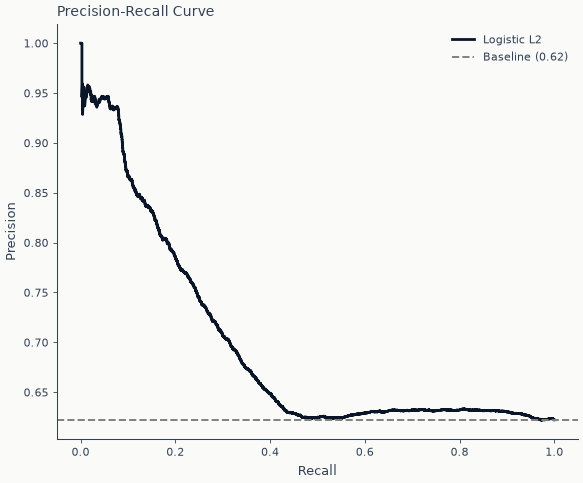

In [23]:
# Manual precision-recall sweep, same rationale as the ROC cell above.
_pr_order = np.argsort(-all_y_prob, kind="mergesort")
_pr_yt = all_y_true[_pr_order].astype(np.int64)
_tps = np.cumsum(_pr_yt)
prec = _tps / np.arange(1, len(_pr_yt) + 1)
rec = _tps / int(_pr_yt.sum())
baseline = all_y_true.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, linewidth=2, label="Logistic L2")
ax.axhline(baseline, ls="--", color="grey", label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
fig.tight_layout()
fig.show()

## L1 Feature Importance

The L1 logistic model zeroes out unimportant features. Comparing the
surviving features with the LASSO regression results from NB02 shows
whether the same signals matter for direction prediction.

In [24]:
l1_coeffs = l1_all[best_l1_C]["coeffs"]  # (n_folds, n_features)
mean_abs = np.abs(l1_coeffs).mean(axis=0)
mean_signed = l1_coeffs.mean(axis=0)

importance = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "mean_abs_coeff": mean_abs,
        "mean_signed_coeff": mean_signed,
    }
).sort("mean_abs_coeff", descending=True)

nonzero = importance.filter(pl.col("mean_abs_coeff") > 1e-8)
print(f"Non-zero features: {nonzero.height}/{len(FEATURE_COLS)} at C={best_l1_C}")
nonzero.head(15)

Non-zero features: 57/57 at C=10.0


feature,mean_abs_coeff,mean_signed_coeff
str,f64,f64
"""vol_63d""",0.878165,-0.256032
"""sma_ratio_200""",0.73339,-0.73339
"""dist_52w_high""",0.591556,0.591556
"""dist_52w_low""",0.553331,0.553331
"""vol_126d""",0.521552,0.266568
"""bb_pctb_20""",0.399824,-0.399772
"""rsi_14""",0.343961,0.32714
"""sharpe_189d""",0.339196,-0.339196
"""stoch_k""",0.325884,-0.325884


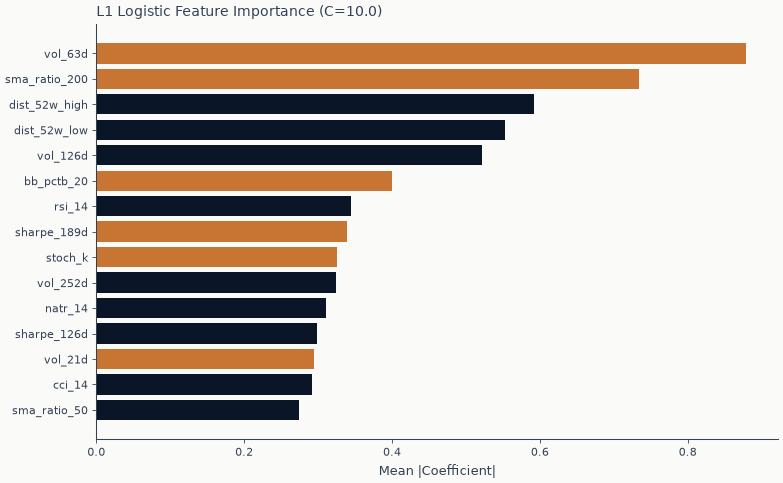

In [25]:
top15 = importance.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [
    COLORS["blue"] if v >= 0 else COLORS["copper"] for v in top15["mean_signed_coeff"].to_list()
]
ax.barh(range(len(top15)), top15["mean_abs_coeff"].to_list(), color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"].to_list())
ax.invert_yaxis()
ax.set_xlabel("Mean |Coefficient|")
ax.set_title(f"L1 Logistic Feature Importance (C={best_l1_C})")
fig.tight_layout()
fig.show()

## Probability Calibration

For a well-calibrated classifier, predicted probabilities should match
observed frequencies. If the model says "70% chance of going up," we
should see ~70% of those outcomes actually go up. Good calibration is
essential for converting probabilities into position sizes.

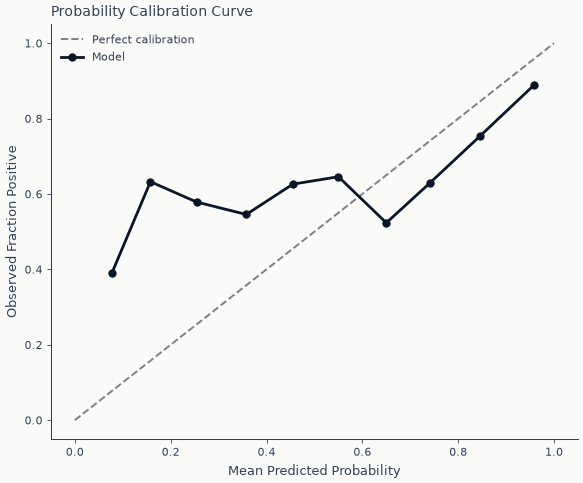

In [26]:
cal_fracs, cal_means = calibration_curve(all_y_true, all_y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Perfect calibration")
ax.plot(cal_means, cal_fracs, "o-", linewidth=2, markersize=6, label="Model")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction Positive")
ax.set_title("Probability Calibration Curve")
ax.legend()
fig.tight_layout()
fig.show()

**Interpretation**: A curve above the diagonal means the model is
under-confident (actual positive rate exceeds predicted probability),
while a curve below means over-confidence. Logistic regression is
generally well-calibrated because its loss function directly optimizes
for probability estimation.

### Platt Scaling Correction

`CalibratedClassifierCV(method='sigmoid')` fits a logistic function to the
model's raw outputs — Platt scaling. We compare the original and corrected
calibration curves on the last fold.

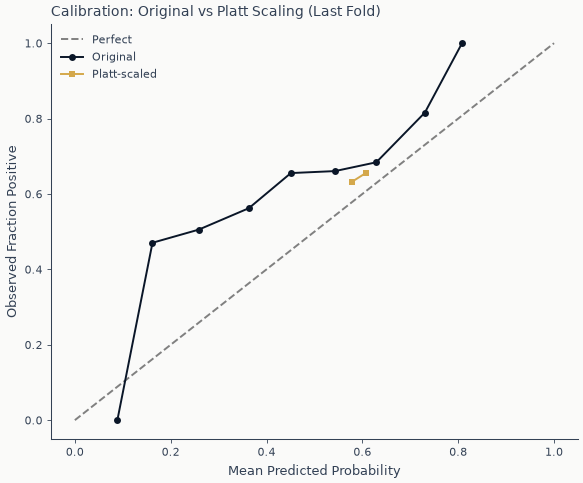

In [27]:
tr_last, te_last = cv_splits[-1]
scaler_platt = StandardScaler()
X_tr_platt = scaler_platt.fit_transform(features_array[tr_last])
X_te_platt = scaler_platt.transform(features_array[te_last])
y_te_platt = target_array[te_last]

base_model = LogisticRegression(
    C=best_l2_C,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_SEED,
)
cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv=3)
cal_model.fit(X_tr_platt, target_array[tr_last])
y_prob_platt = cal_model.predict_proba(X_te_platt)[:, 1]

# Original (uncalibrated) model on the same test set for fair comparison
orig_model = LogisticRegression(
    C=best_l2_C,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_SEED,
)
orig_model.fit(X_tr_platt, target_array[tr_last])
y_prob_orig = orig_model.predict_proba(X_te_platt)[:, 1]

frac_orig, mean_orig = calibration_curve(y_te_platt, y_prob_orig, n_bins=10)
frac_platt, mean_platt = calibration_curve(y_te_platt, y_prob_platt, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Perfect")
ax.plot(mean_orig, frac_orig, "o-", label="Original", markersize=5)
ax.plot(mean_platt, frac_platt, "s-", label="Platt-scaled", markersize=5)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction Positive")
ax.set_title("Calibration: Original vs Platt Scaling (Last Fold)")
ax.legend()
fig.tight_layout()
fig.show()

### Hit Rate by Confidence

If the classifier is informative, accuracy should increase with prediction
confidence (distance from 0.5). We bin pooled out-of-sample predictions
by confidence and check for monotonicity.

In [28]:
confidence = np.abs(all_y_prob - 0.5)
bin_edges = np.quantile(confidence, np.linspace(0, 1, 6))
bin_edges[0] = -0.001  # include zero
bin_labels = np.digitize(confidence, bin_edges) - 1

hit_rows = []
for b in range(5):
    mask = bin_labels == b
    if mask.sum() > 0:
        acc = (all_y_pred[mask] == all_y_true[mask]).mean()
        hit_rows.append(
            {
                "quintile": b + 1,
                "confidence": f"{bin_edges[b]:.3f}–{bin_edges[b + 1]:.3f}",
                "n_samples": int(mask.sum()),
                "accuracy": round(acc, 4),
            }
        )

hit_table = pl.DataFrame(hit_rows)
hit_table

quintile,confidence,n_samples,accuracy
i64,str,i64,f64
1,"""-0.001–0.045""",3831,0.5147
2,"""0.045–0.096""",3830,0.5352
3,"""0.096–0.156""",3830,0.4901
4,"""0.156–0.241""",3830,0.5496
5,"""0.241–0.500""",3830,0.7149


Accuracy is roughly flat across the lower four quintiles (~0.49–0.55) and
jumps sharply in the top quintile (~0.71). The non-monotone dip in Q3 (0.49,
about 4.5 pp below Q2 and 6 pp below Q4) is far larger than the ~0.8 pp
binomial standard error of a ~3,800-sample bin, so it is a genuine feature of
the model's miscalibration inside the central band, not sampling noise. Either
way, the lack of a clean monotone climb across Q1–Q4 says the model's
*graduated* confidence there carries little usable ranking information. The
top-quintile jump is what makes the signal usable: a strategy that trades
only in the highest-confidence bucket captures ~71% accuracy at the cost of
~80% turnover reduction. That tradeoff motivates the threshold-based
signal in the next section.

### From Probabilities to Trading Signals

The same model produces different portfolios depending on how probabilities
are converted to positions. We demonstrate three common approaches on the
last fold: threshold-based, probability-weighted, and rank-based.

In [29]:
last_prob = l2_all[best_l2_C]["predictions"][-1]["y_prob"]
n_sig = len(last_prob)

# Three conversion methods
thresh_long = last_prob > 0.55
thresh_short = last_prob < 0.45
prob_signal = last_prob - 0.5
ranks = np.argsort(np.argsort(last_prob)) / n_sig
rank_long = ranks >= 0.8
rank_short = ranks < 0.2

print(f"Last fold: {n_sig:,} predictions\n")
print(
    f"Threshold (0.45/0.55): {thresh_long.sum():,} long, {thresh_short.sum():,} short, {(~thresh_long & ~thresh_short).sum():,} flat"
)
print(f"Rank-based (20/20):    {rank_long.sum():,} long, {rank_short.sum():,} short")
print(f"Prob-weighted:         all {n_sig:,} have non-zero weight (mean: {prob_signal.mean():.4f})")
overlap = (thresh_long & rank_long).sum()
print(
    f"\nThreshold-long ∩ rank-long overlap: {overlap}/{thresh_long.sum()} ({overlap / max(thresh_long.sum(), 1):.0%})"
)

Last fold: 2,520 predictions

Threshold (0.45/0.55): 1,193 long, 466 short, 861 flat
Rank-based (20/20):    504 long, 504 short
Prob-weighted:         all 2,520 have non-zero weight (mean: 0.0753)

Threshold-long ∩ rank-long overlap: 504/1193 (42%)


The three methods produce substantially different portfolios from the same
predictions. The choice depends on strategy constraints (position limits,
turnover targets, liquidity). Chapter 17 develops the full framework.

## Classification Summary: ROC and Calibration

A composite figure showing the ROC curve and calibration plot side by side.

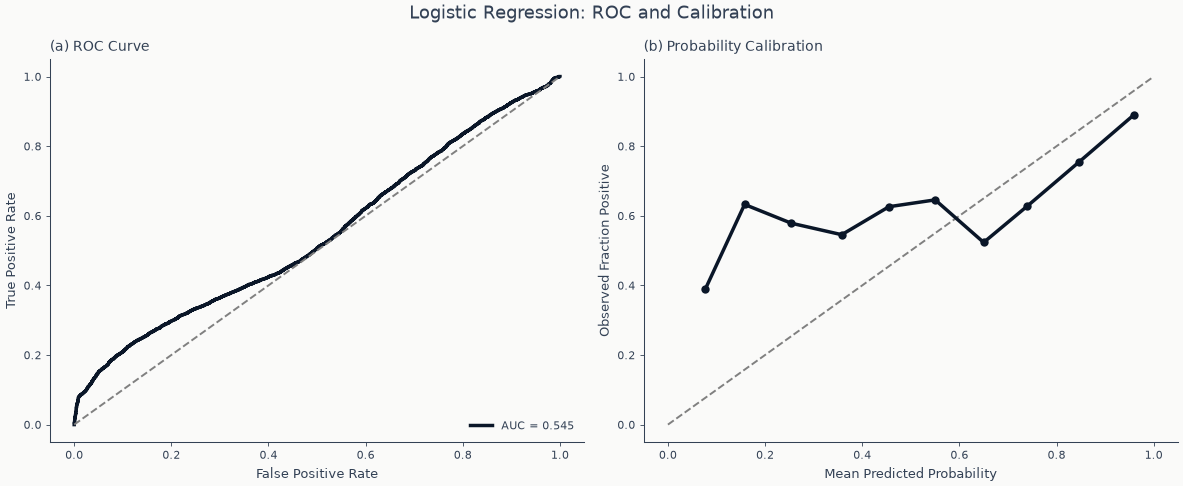

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: ROC
ax = axes[0]
ax.plot(fpr, tpr, linewidth=2.5, label=f"AUC = {auc_val:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="grey")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(a) ROC Curve")
ax.legend(loc="lower right")

# Panel B: Calibration
ax = axes[1]
ax.plot([0, 1], [0, 1], ls="--", color="grey")
ax.plot(cal_means, cal_fracs, "o-", linewidth=2.5, markersize=6)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction Positive")
ax.set_title("(b) Probability Calibration")

fig.suptitle("Logistic Regression: ROC and Calibration", fontsize=13)
fig.tight_layout()
fig.show()

**Interpretation**: the ROC curve sits above the 45° random-classifier line
across the threshold range, with pooled AUC matching the cross-validated AUC
of $\approx 0.57$ reported in the L2 sweep above. The calibration plot shows
predicted probabilities tracking observed frequencies closely — a prerequisite
for confidence-based position sizing (Section 11.3).

## Multinomial Extension: Ternary Direction

Binary up/down discards information about return magnitude. A multinomial
logistic model with three classes (bottom/middle/top tercile) retains the
ordinal structure and maps naturally to the softmax formulation in Section 11.3.

In [31]:
tr_last, te_last = cv_splits[-1]
y_ret_train = return_array[tr_last]
y_ret_test = return_array[te_last]

tercile_edges = np.quantile(y_ret_train, [1 / 3, 2 / 3])
y_tern_train = np.digitize(y_ret_train, tercile_edges)  # 0=bottom, 1=mid, 2=top
y_tern_test = np.digitize(y_ret_test, tercile_edges)

scaler_mn = StandardScaler()
X_tr_mn = scaler_mn.fit_transform(features_array[tr_last])
X_te_mn = scaler_mn.transform(features_array[te_last])

model_mn = LogisticRegression(
    solver="lbfgs",
    C=best_l2_C,
    max_iter=1000,
    random_state=RANDOM_SEED,
)
model_mn.fit(X_tr_mn, y_tern_train)
y_pred_mn = model_mn.predict(X_te_mn)

print("Multinomial Logistic (ternary direction, last fold):\n")
print(classification_report(y_tern_test, y_pred_mn, target_names=["Bottom", "Middle", "Top"]))

Multinomial Logistic (ternary direction, last fold):

              precision    recall  f1-score   support

      Bottom       0.29      0.63      0.40      5866
      Middle       0.58      0.58      0.58      8340
         Top       0.56      0.07      0.12      7964

    accuracy                           0.41     22170
   macro avg       0.48      0.43      0.37     22170
weighted avg       0.50      0.41      0.37     22170



**Interpretation**: overall accuracy is ~0.41, modestly above the 1/3 random
baseline but driven almost entirely by the Bottom and Middle classes. The Top
tercile collapses to f1 ≈ 0.13 with recall near 0.07 — the model almost never
predicts a top-tercile return even when one occurs, even though when it does
the prediction is correct ~56% of the time. The Bottom class shows the
opposite pathology: recall ~0.63 with precision only ~0.29, meaning the model
over-predicts Bottom on ambiguous cases. The asymmetry reflects the upward
drift in 21-day ETF returns combined with vanilla multinomial loss; recovering
extremes requires class reweighting, an explicit ordinal loss, or the
rank-based mapping introduced above.

## Key Takeaways

1. **Direction prediction** reframes the return forecasting problem as binary
   classification. With 21-day ETF returns, the "up" class dominates (~59/41
   over the full sample), so a naive majority-class baseline already achieves
   ~59% accuracy — models must beat this to demonstrate skill. (The base rate
   drifts to ~62/38 within the later out-of-sample folds, which is why the
   pooled confusion matrix leans more heavily toward "up".)

2. **L2 logistic regression** keeps all features and is well-suited when many
   correlated signals each contribute a small amount. L1 can produce sparsity at
   stronger regularization (C=0.001 selects 8 features), but at the AUC-optimal C
   all features remain active — the sparsity-performance tradeoff is real.

3. **AUC-ROC** is more informative than raw accuracy because it evaluates
   discrimination across all probability thresholds. An AUC of 0.5 is what a
   constant or coin-flip predictor obtains by definition; the cross-validated
   AUC here is $\approx 0.57$, above that null reference but well short of
   the 0.7–0.8 range typical of strong classifiers on less noisy domains.

4. **Probability calibration** matters for position sizing: a calibrated model
   lets you scale positions by prediction confidence. The calibration plot
   above shows the L2 logistic model's predicted probabilities tracking
   observed frequencies closely on this dataset; log-loss optimization
   encourages but does not guarantee calibration, so the diagnostic still
   matters.

5. **Same walk-forward folds as NB02** ensures fair comparison between regression
   and classification approaches to the same prediction task.

**Next**: `04_nested_cv_hpo` adds Optuna-based hyperparameter optimization
with proper nested cross-validation to control selection bias.